## 1.0 — Imports e Configurações

In [27]:
import numpy as np
import pandas as pd
import random
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("white")  
sns.set_context("talk")  

# Seed fixo para reprodutibilidade
seed = 42
np.random.seed(seed)
random.seed(seed)
N = 1000

## 1.1 — Dataset

Os dados abaixo simulam **1000 leituras** do sistema de telemetria da nave Aurora Siger, cobrindo os parâmetros definidos no protocolo de pré-decolagem.

| Parâmetro | Faixa Segura |
|---|---|
| Temperatura interna | 15 – 30 °C |
| Temperatura externa | -20 – 40 °C |
| Integridade estrutural | 1 |
| Nível de energia | ≥ 80% |
| Pressão dos tanques | 3 – 5 bar |
| Módulo de Navegação | 1 |
| Módulo de Comunicação | 1 |
| Módulo de Propulsão | 1 |

In [10]:
temp_interna = np.concatenate([
    np.random.uniform(15, 30, 900),
    np.random.uniform(5, 14, 50),
    np.random.uniform(31, 40, 50)
])

temp_externa = np.concatenate([
    np.random.uniform(-20, 40, 920),
    np.random.uniform(-35, -21, 40),
    np.random.uniform(41, 55, 40)
])

integridade = np.random.choice([0, 1], size=N, p=[0.05, 0.95])

energia = np.concatenate([
    np.random.uniform(80, 100, 850),
    np.random.uniform(50, 79.9, 150)
])

pressao = np.concatenate([
    np.random.uniform(3.0, 5.0, 880),
    np.random.uniform(1.0, 2.9, 60),
    np.random.uniform(5.1, 7.0, 60)
])

mod_navegacao   = np.random.choice([0, 1], size=N, p=[0.04, 0.96])
mod_comunicacao = np.random.choice([0, 1], size=N, p=[0.04, 0.96])
mod_propulsao   = np.random.choice([0, 1], size=N, p=[0.04, 0.96])

indices = np.arange(N)
np.random.shuffle(indices)

df = pd.DataFrame({
    'leitura_id'      : range(1, N + 1),
    'temp_interna'    : temp_interna[indices].round(2),
    'temp_externa'    : temp_externa[indices].round(2),
    'integridade'     : integridade[indices],
    'energia_pct'     : energia[indices].round(2),
    'pressao_bar'     : pressao[indices].round(3),
    'mod_navegacao'   : mod_navegacao[indices],
    'mod_comunicacao' : mod_comunicacao[indices],
    'mod_propulsao'   : mod_propulsao[indices],
})

df.head(10)

,leitura_id,temp_interna,temp_externa,integridade,energia_pct,pressao_bar,mod_navegacao,mod_comunicacao,mod_propulsao
0,1,35.65,48.86,1,53.27,6.952,1,1,1
1,2,19.05,7.93,1,96.93,3.588,1,1,1
2,3,27.10,24.60,1,83.62,4.829,1,1,1
3,4,5.77,1.66,1,54.50,2.187,1,1,1
4,5,28.53,10.01,1,90.43,3.384,1,1,1
5,6,23.30,38.80,1,60.08,1.026,1,1,0
6,7,28.80,-0.07,1,86.59,4.138,1,1,1
7,8,27.59,38.84,1,92.39,3.380,1,1,1
8,9,28.21,-7.99,1,99.02,3.397,1,1,1
9,10,27.62,-1.08,1,88.94,3.088,1,1,1


## 1.2 — Verificações

In [15]:
temp_interna_ok    = (df['temp_interna'] >= 15.0) & (df['temp_interna'] <= 30.0)
temp_externa_ok    = (df['temp_externa'] >= -20.0) & (df['temp_externa'] <= 40.0)
integridade_ok     = df['integridade'] == 1
energia_ok         = df['energia_pct'] >= 80.0
pressao_ok         = (df['pressao_bar'] >= 3.0) & (df['pressao_bar'] <= 5.0)
mod_navegacao_ok   = df['mod_navegacao'] == 1
mod_comunicacao_ok = df['mod_comunicacao'] == 1
mod_propulsao_ok   = df['mod_propulsao'] == 1

sistemas_ok = (
    mod_navegacao_ok
    & mod_comunicacao_ok
    & mod_propulsao_ok
)

condicoes_ok = (
    temp_interna_ok
    & temp_externa_ok
    & integridade_ok
    & energia_ok
    & pressao_ok
)

df['status'] = 'DECOLAGEM ABORTADA'
df.loc[sistemas_ok & condicoes_ok, 'status'] = 'PRONTO PARA DECOLAR'

df.status.head()

0     DECOLAGEM ABORTADA
1    PRONTO PARA DECOLAR
2    PRONTO PARA DECOLAR
3     DECOLAGEM ABORTADA
4    PRONTO PARA DECOLAR
Name: status, dtype: object

## 1.3 — Tipos de falha

In [41]:
CHECKS = {
    'temp_interna'    : lambda v: 15.0 <= v <= 30.0,
    'temp_externa'    : lambda v: -20.0 <= v <= 40.0,
    'integridade'     : lambda v: v == 1,
    'energia_pct'     : lambda v: v >= 80.0,
    'pressao_bar'     : lambda v: 3.0 <= v <= 5.0,
    'mod_navegacao'   : lambda v: v == 1,
    'mod_comunicacao' : lambda v: v == 1,
    'mod_propulsao'   : lambda v: v == 1,
}

df['falhas'] = df.apply(
    lambda row: [p for p, fn in CHECKS.items() if not fn(row[p])],
    axis=1
)

df.loc[df['status'] == 'DECOLAGEM ABORTADA', ['leitura_id', 'status', 'falhas']].head(15)

,leitura_id,status,falhas
0,1,DECOLAGEM ABORTADA,"[temp_interna, temp_externa, energia_pct, pres..."
3,4,DECOLAGEM ABORTADA,"[temp_interna, energia_pct, pressao_bar]"
5,6,DECOLAGEM ABORTADA,"[energia_pct, pressao_bar, mod_propulsao]"
13,14,DECOLAGEM ABORTADA,[mod_navegacao]
20,21,DECOLAGEM ABORTADA,[mod_comunicacao]
21,22,DECOLAGEM ABORTADA,"[temp_interna, temp_externa, energia_pct, pres..."
24,25,DECOLAGEM ABORTADA,"[temp_interna, temp_externa, energia_pct, pres..."
32,33,DECOLAGEM ABORTADA,"[integridade, mod_navegacao]"
33,34,DECOLAGEM ABORTADA,"[temp_interna, temp_externa, energia_pct, pres..."
36,37,DECOLAGEM ABORTADA,"[temp_interna, temp_externa, energia_pct, pres..."


## 1.4 — Visualizando

/tmp/ipykernel_2307/586076280.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_2307/586076280.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


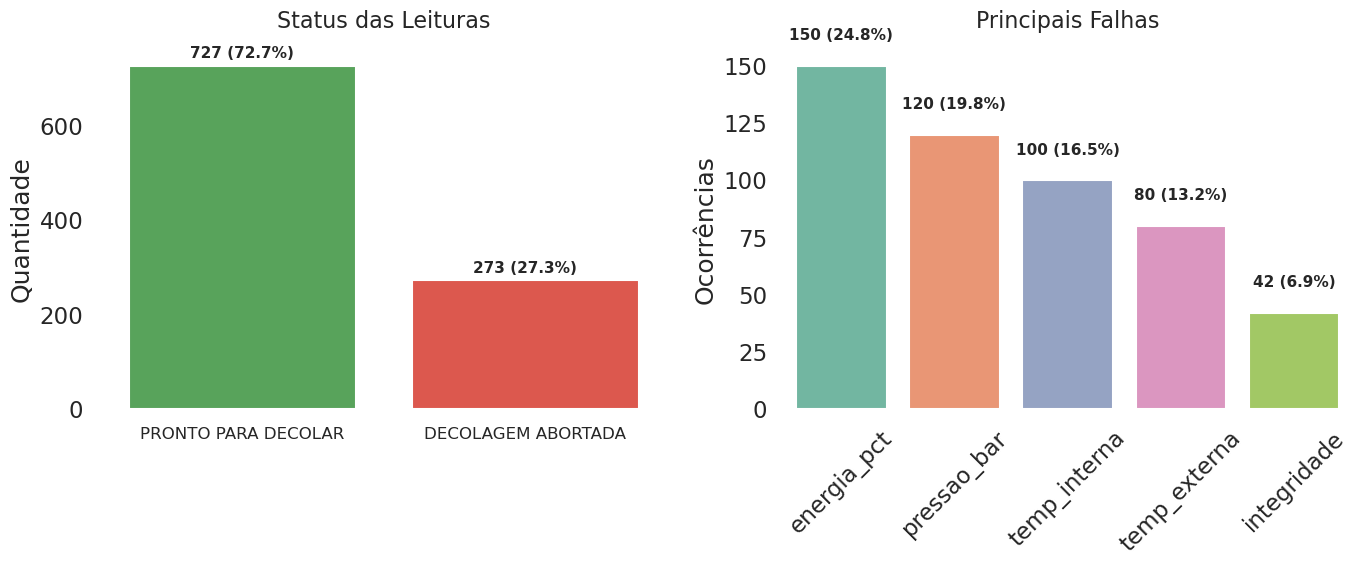

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Dados
status_counts = df['status'].value_counts().reset_index()
status_counts.columns = ['status', 'count']
status_counts['pct'] = status_counts['count'] / status_counts['count'].sum() * 100

falhas_flat = [f for lista in df['falhas'] for f in lista]
falhas_counts = pd.Series(falhas_flat).value_counts().reset_index()
falhas_counts.columns = ['falha', 'count']
falhas_counts['pct'] = falhas_counts['count'] / falhas_counts['count'].sum() * 100
falhas_counts_top5 = falhas_counts.head(5)

status_colors = {'PRONTO PARA DECOLAR': '#4CAF50',  
                 'DECOLAGEM ABORTADA': '#F44336'}   
falhas_colors = sns.color_palette('Set2', n_colors=len(falhas_counts_top5))

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Status das leituras
sns.barplot(
    x='status', y='count', data=status_counts, ax=axes[0],
    palette=[status_colors[s] for s in status_counts['status']]
)
axes[0].set_title('Status das Leituras', fontsize=16, pad=15)
axes[0].set_xlabel('')
axes[0].set_ylabel('Quantidade')
axes[0].tick_params(axis='x', labelsize=12)
axes[0].grid(False)  
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].spines['left'].set_visible(False)
axes[0].spines['bottom'].set_visible(False)

# Valores e porcentagens sobre as barras
for i, row in status_counts.iterrows():
    axes[0].text(i, row['count'] + total*0.01, f"{row['count']} ({row['pct']:.1f}%)",
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

# Principais falhas
sns.barplot(
    x='falha', y='count', data=falhas_counts_top5, ax=axes[1],
    palette=falhas_colors
)
axes[1].set_title('Principais Falhas', fontsize=16, pad=15)
axes[1].set_xlabel('')
axes[1].set_ylabel('Ocorrências')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(False)  
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['left'].set_visible(False)
axes[1].spines['bottom'].set_visible(False)

for i, row in falhas_counts_top5.iterrows():
    axes[1].text(i, row['count'] + total*0.01, f"{row['count']} ({row['pct']:.1f}%)",
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 1.5 — Analise energetica

In [40]:
cap_total = 1500
carga_media = df['energia_pct'].mean()
consumo_decolagem = 700
perdas_pct = 8

energia_disponivel = cap_total * carga_media / 100
perdas = energia_disponivel * perdas_pct / 100
energia_real = energia_disponivel - perdas
margem = energia_real - consumo_decolagem
autonomia_ok = energia_real >= consumo_decolagem

energia_resultado = {
    'capacidade_total_kwh'  : cap_total,
    'carga_atual_pct'       : round(carga_media, 1),
    'energia_disponivel_kwh': round(energia_disponivel, 2),
    'perdas_kwh'            : round(perdas, 2),
    'energia_real_kwh'      : round(energia_real, 2),
    'consumo_decolagem_kwh' : consumo_decolagem,
    'margem_kwh'            : round(margem, 2),
    'autonomia_suficiente'  : autonomia_ok
}

energia_resultado

{'capacidade_total_kwh': 1500,
 'carga_atual_pct': np.float64(86.1),
 'energia_disponivel_kwh': np.float64(1290.83),
 'perdas_kwh': np.float64(103.27),
 'energia_real_kwh': np.float64(1187.57),
 'consumo_decolagem_kwh': 700,
 'margem_kwh': np.float64(487.57),
 'autonomia_suficiente': np.True_}

- **Capacidade total**        : 1500 kWh  
- **Carga atual (média)**     : 86.1%  
- **Energia disponível**      : 1290.83 kWh  
- **Perdas (8%)**             : 103.27 kWh  
- **Energia real utilizável** : 1187.57 kWh  
- **Consumo de decolagem**    : 700 kWh  
- **Margem energética**       : 487.57 kWh  
- **Autonomia suficiente**    : 🟢 Sim